# Calibration Curves by Subject

Visualize isotonic vs. kernel-smoothed reliability curves. Identify subjects where the monotonicity assumption diverges from the unconstrained fit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = 'gpt4o'  # or 'llama'
curves = pd.read_parquet(f'../data/processed/calibration_curves_{MODEL}.parquet')
summaries = pd.read_parquet(f'../data/processed/subject_summaries_{MODEL}.parquet')
summaries.head(10)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,subject,domain,n,ece,mean_gap,mean_confidence,mean_accuracy
0,moral_scenarios,Humanities,895,0.483082,0.483082,0.922188,0.439106
1,virology,Other,166,0.431504,0.442346,0.972466,0.530120
2,abstract_algebra,STEM,100,0.426208,0.466208,0.846208,0.380000
3,global_facts,Other,100,0.400982,0.400982,0.920982,0.520000
4,formal_logic,Humanities,126,0.390356,0.414166,0.930039,0.515873
5,professional_law,Humanities,1534,0.379648,0.379648,0.950704,0.571056
6,machine_learning,STEM,112,0.375261,0.369532,0.949889,0.580357
7,college_physics,STEM,102,0.347894,0.348275,0.897295,0.549020
8,college_chemistry,STEM,100,0.347784,0.347784,0.867784,0.520000
9,econometrics,Social Sciences,114,0.327491,0.329766,0.952573,0.622807


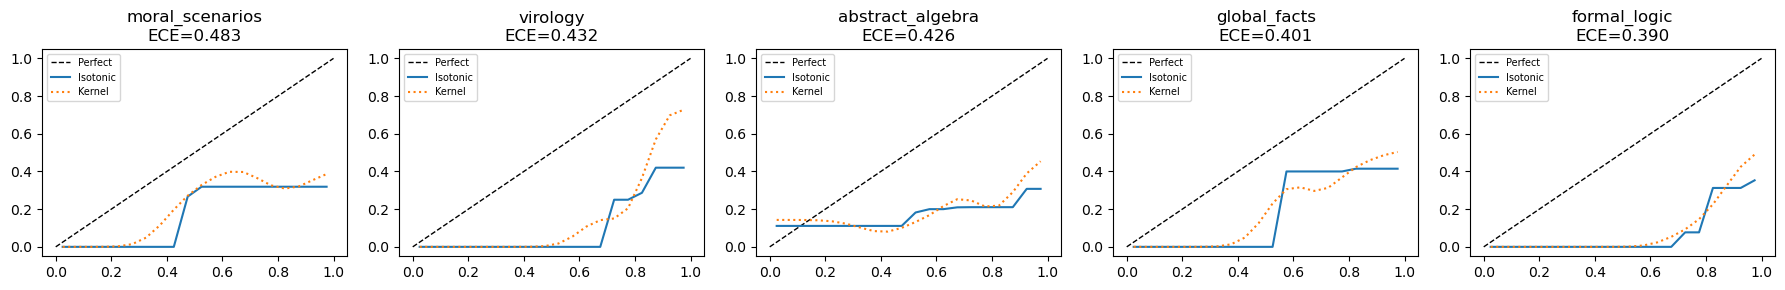

In [2]:
def plot_curve(row, ax):
    bins = np.array(row['confidence_bins'])
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
    ax.plot(bins, row['isotonic_acc'], label='Isotonic')
    ax.plot(bins, row['kernel_acc'], label='Kernel', linestyle=':')
    ax.set_title(f"{row['subject']}\nECE={row['ece']:.3f}")
    ax.legend(fontsize=7)

# Plot top-5 most miscalibrated subjects
top5 = curves.nlargest(5, 'ece')
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, (_, row) in zip(axes, top5.iterrows()):
    plot_curve(row, ax)
plt.tight_layout()
plt.savefig(f'../report/figures/top5_miscalibrated_{MODEL}.pdf', bbox_inches='tight')